# Student Placement Dataset Exploration & Modeling

### **Link Video :**  https://drive.google.com/drive/folders/1zZrHWWbnf1sHSNFTfYyOJe_g0cwrJdn5?usp=sharing

## 1. Setup & Data Loading

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print('Libraries loaded.')

Libraries loaded.


In [2]:
from src.data.loader import ingest_data, load_frame

ingest_data()

df = load_frame()

print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Data ingested: B.csv → C:\Users\valen\OneDrive\Desktop\Homework\Model Deployment\PROJECT UTS\tokokelontong\data\ingested\B.csv
Shape: (5000, 18)
Placement rate: 17.3%
Loaded dataset: 5,000 rows × 18 columns


,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


## 2. Dataset Overview

In [3]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows, {df.shape[1]} columns\n')

print('=== Data Types ===')
print(df.dtypes.to_string())

=== Shape ===
5,000 rows, 18 columns

=== Data Types ===
student_id                      int64
gender                         object
ssc_percentage                  int64
hsc_percentage                  int64
degree_percentage               int64
cgpa                          float64
entrance_exam_score             int64
technical_skill_score           int64
soft_skill_score                int64
internship_count                int64
live_projects                   int64
work_experience_months          int64
certifications                  int64
attendance_percentage           int64
backlogs                        int64
extracurricular_activities     object
placement_status                int64
salary_package_lpa            float64


In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
student_id,5000.000000,2500.500000,1443.520003,1.000000,1250.750000,2500.500000,3750.250000,5000.000000
ssc_percentage,5000.000000,72.425800,13.199642,50.000000,61.000000,72.000000,84.000000,95.000000
hsc_percentage,5000.000000,71.910800,12.842781,50.000000,61.000000,72.000000,83.000000,94.000000
degree_percentage,5000.000000,71.845200,10.013196,55.000000,63.000000,72.000000,80.000000,89.000000
cgpa,5000.000000,7.678326,1.237084,5.500000,6.617500,7.700000,8.750000,9.800000
entrance_exam_score,5000.000000,69.197800,17.325528,40.000000,54.000000,69.000000,84.000000,99.000000
technical_skill_score,5000.000000,69.651000,17.179704,40.000000,55.000000,70.000000,84.000000,99.000000
soft_skill_score,5000.000000,69.839600,17.170732,40.000000,55.000000,69.000000,85.000000,99.000000
internship_count,5000.000000,1.987800,1.410975,0.000000,1.000000,2.000000,3.000000,4.000000
live_projects,5000.000000,2.491800,1.704967,0.000000,1.000000,3.000000,4.000000,5.000000


In [5]:
df.describe(include='object')

,gender,extracurricular_activities
count,5000,5000
unique,2,2
top,Male,No
freq,2504,2553


## 3. Missing Values

From the dataset overview we can see that the dataset contains **no missing values**. This means we can proceed directly to analysis without any imputation step in EDA.

## 4. Target Distribution

### 4.1 Classification Target - `placement_status`

Placement distribution:
                  Count  Percent
placement_status                
0                  4134     82.7
1                   866     17.3


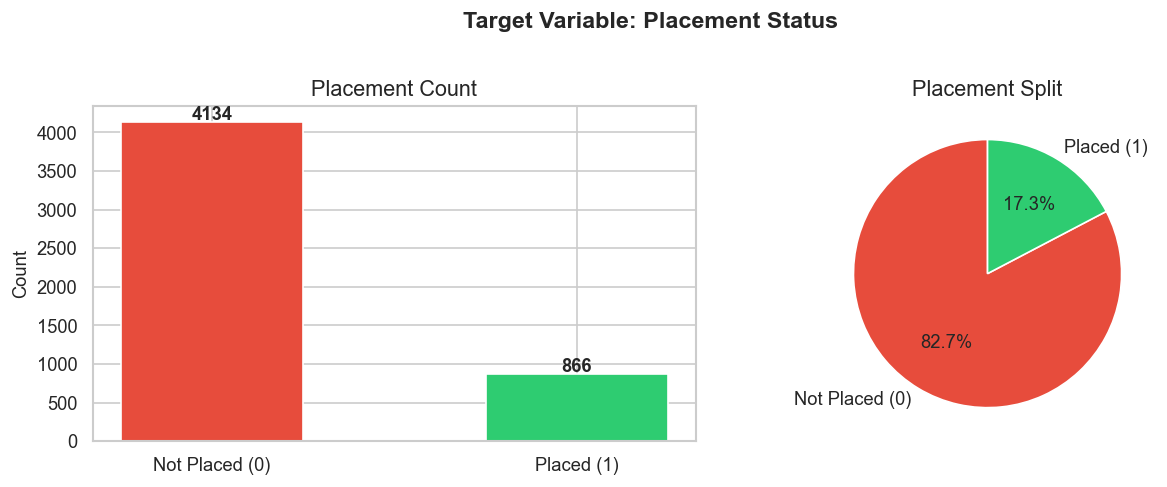

In [6]:
place_counts = df['placement_status'].value_counts()
place_pct = df['placement_status'].value_counts(normalize=True) * 100

print('Placement distribution:')
print(pd.DataFrame({'Count': place_counts, 'Percent': place_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = ['Not Placed (0)', 'Placed (1)']
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(labels, place_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Placement Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(place_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

axes[1].pie(place_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Placement Split')

plt.suptitle('Target Variable: Placement Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The dataset is **highly imbalanced** - only **17.3%** of students (866 out of 5,000) are placed. This means:
- A naive model predicting "Not Placed" for all students achieves ~82.7% accuracy, so accuracy alone is **misleading**.
- We will also report **Precision**, **Recall**, and **F1-score** for a complete evaluation.
- Models should be evaluated with `class_weight='balanced'` or similar techniques if recall for the minority class is important.

### 4.2 Regression Target - `salary_package_lpa`

Placed students: 866

count    866.000
mean       9.214
std        3.481
min        3.010
25%        6.292
50%        9.365
75%       12.190
max       14.990
Name: salary_package_lpa, dtype: float64


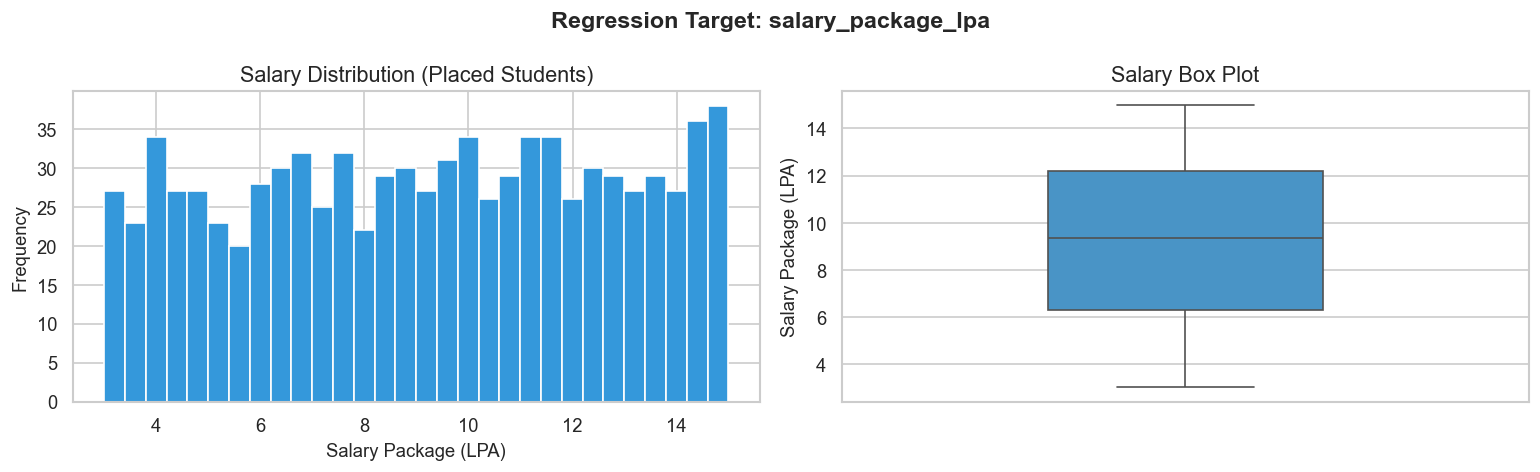

In [7]:
df_placed = df[df['placement_status'] == 1].copy()

print(f'Placed students: {len(df_placed):,}')
print()
print(df_placed['salary_package_lpa'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_placed['salary_package_lpa'], bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Salary Distribution (Placed Students)')
axes[0].set_xlabel('Salary Package (LPA)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df_placed['salary_package_lpa'], ax=axes[1], color='#3498db', width=0.4)
axes[1].set_title('Salary Box Plot')
axes[1].set_ylabel('Salary Package (LPA)')

plt.suptitle('Regression Target: salary_package_lpa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Among placed students, salary ranges from **3.01 to 14.99 LPA** with a mean of ~9.21 LPA. The distribution is **roughly uniform**, which is unusual.

## 5. Numerical Feature Analysis

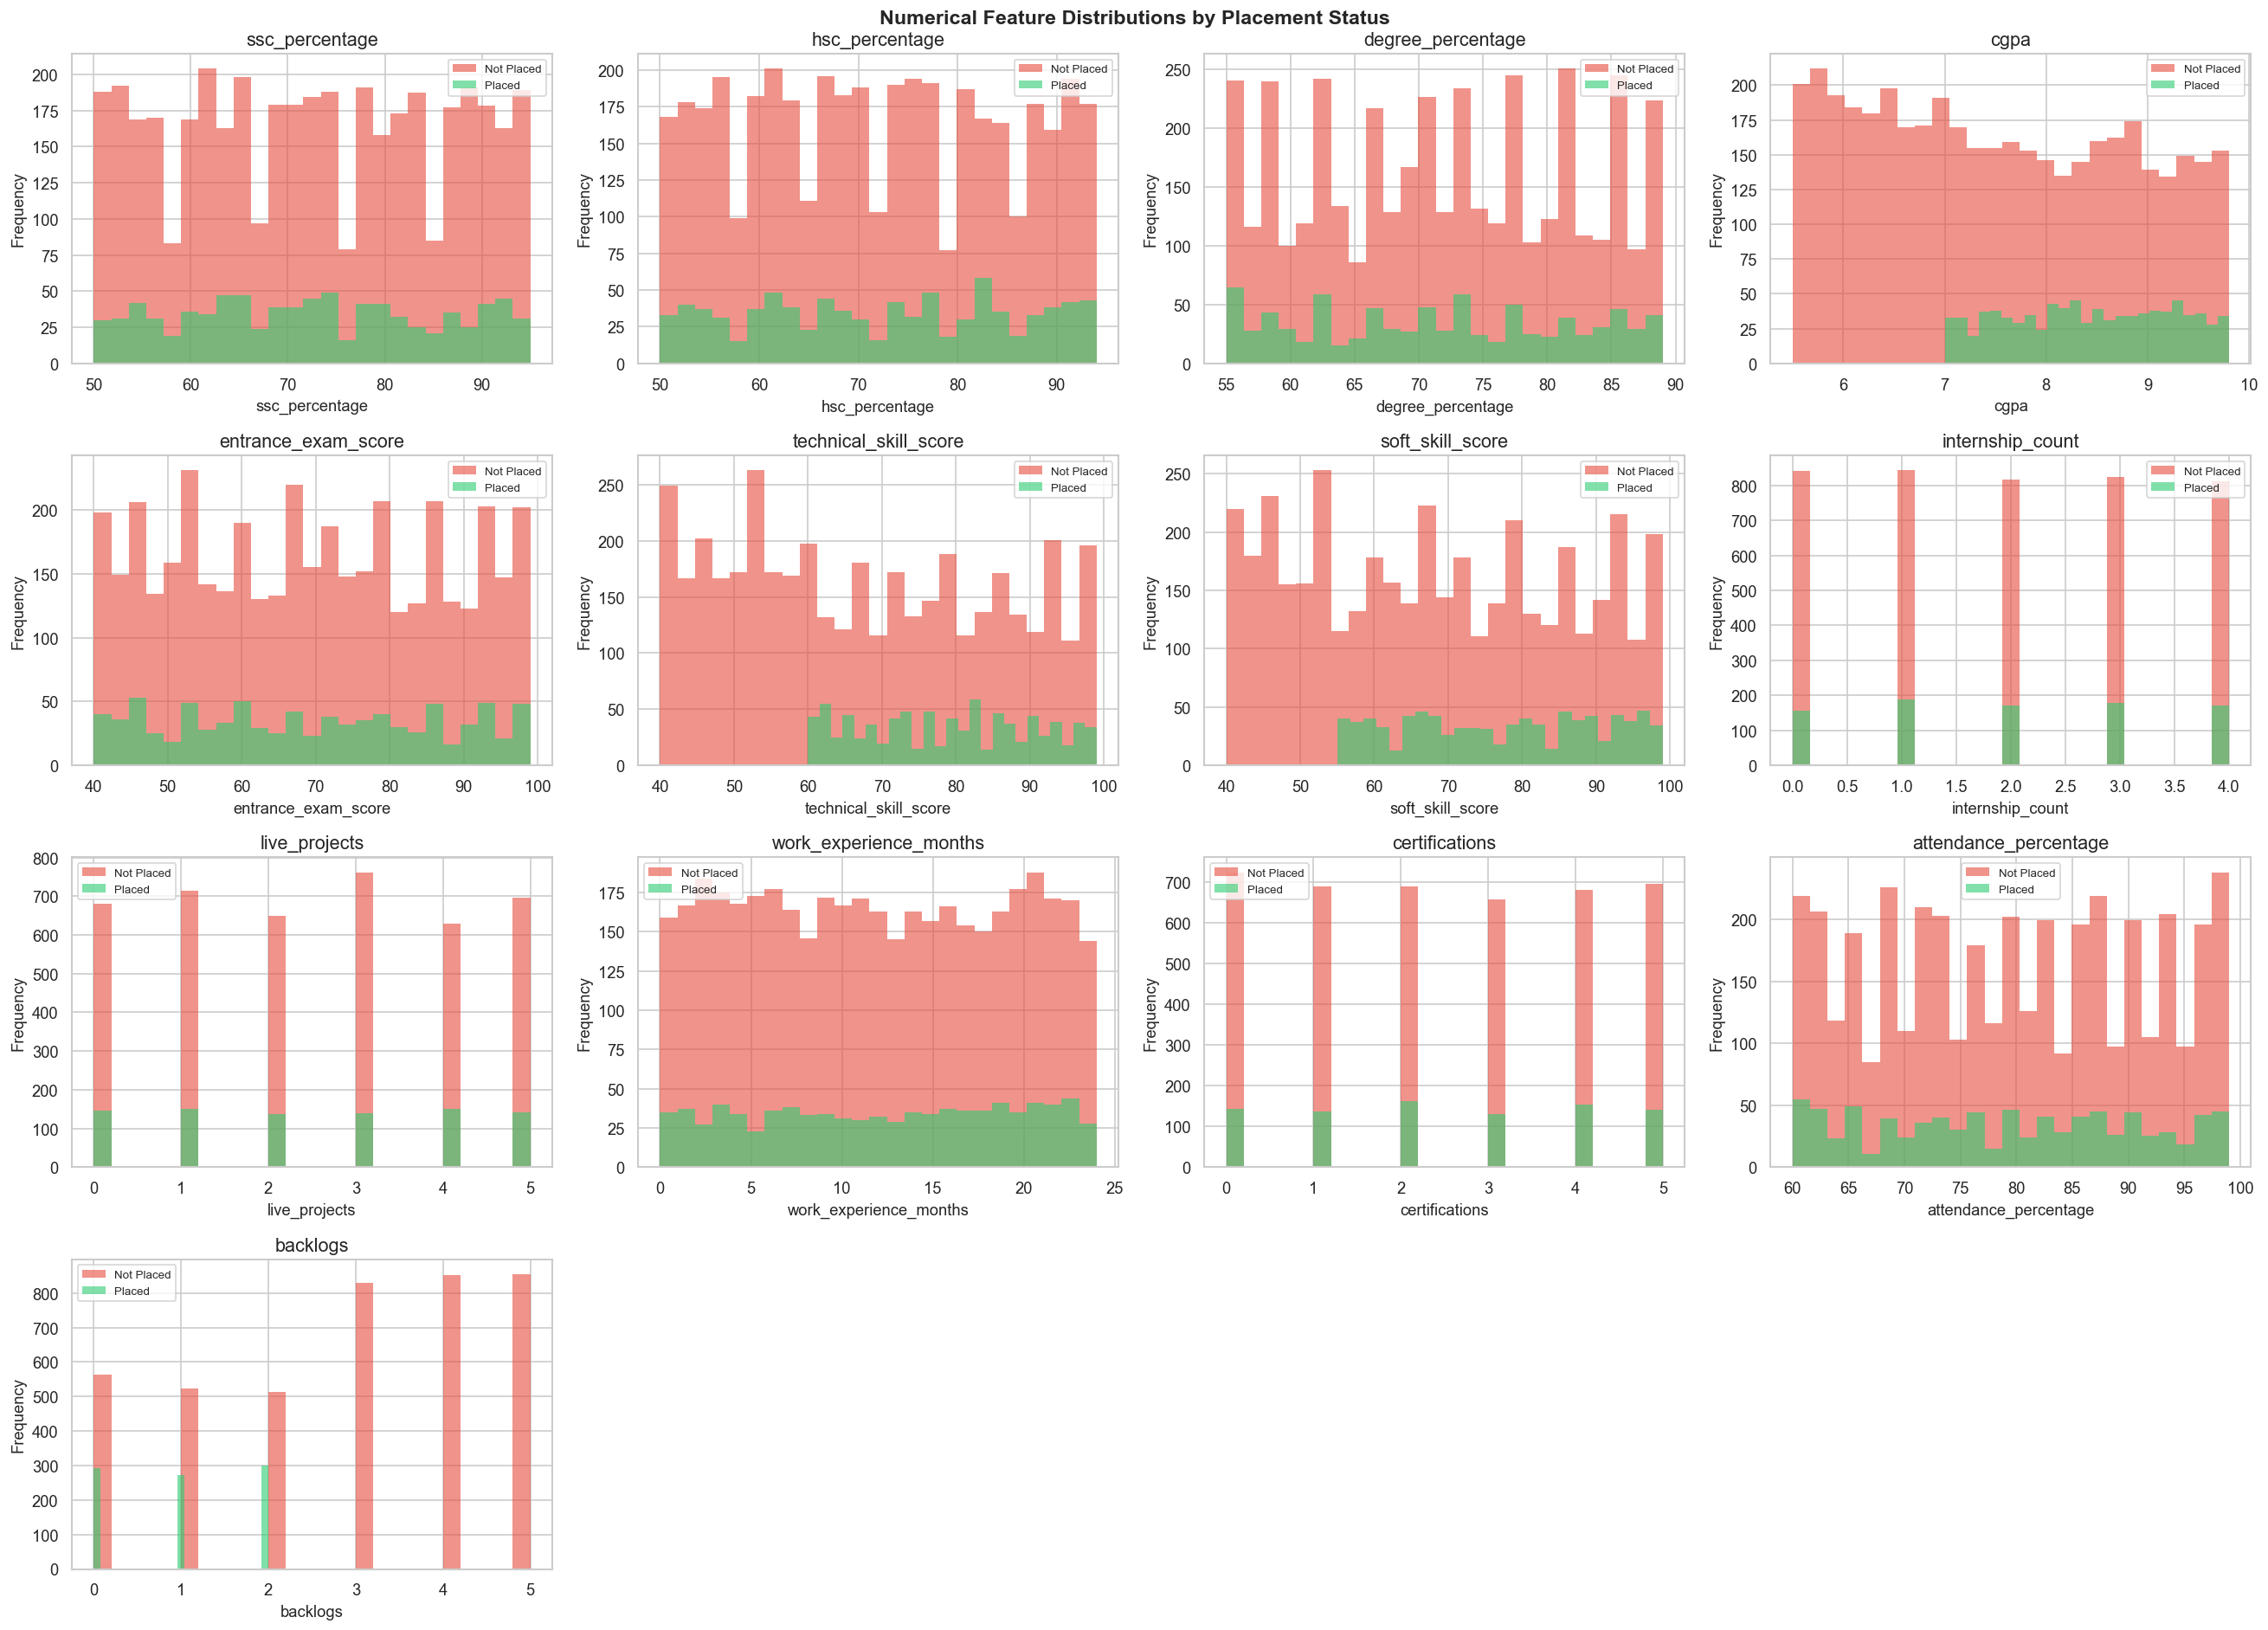

In [8]:
NUM_COLS = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa',
            'entrance_exam_score', 'technical_skill_score', 'soft_skill_score',
            'internship_count', 'live_projects', 'work_experience_months',
            'certifications', 'attendance_percentage', 'backlogs']

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.ravel()

for i, col in enumerate(NUM_COLS):
    for placed_val, color, label in [(0, '#e74c3c', 'Not Placed'), (1, '#2ecc71', 'Placed')]:
        data = df[df['placement_status'] == placed_val][col].dropna()
        axes[i].hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Placement Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

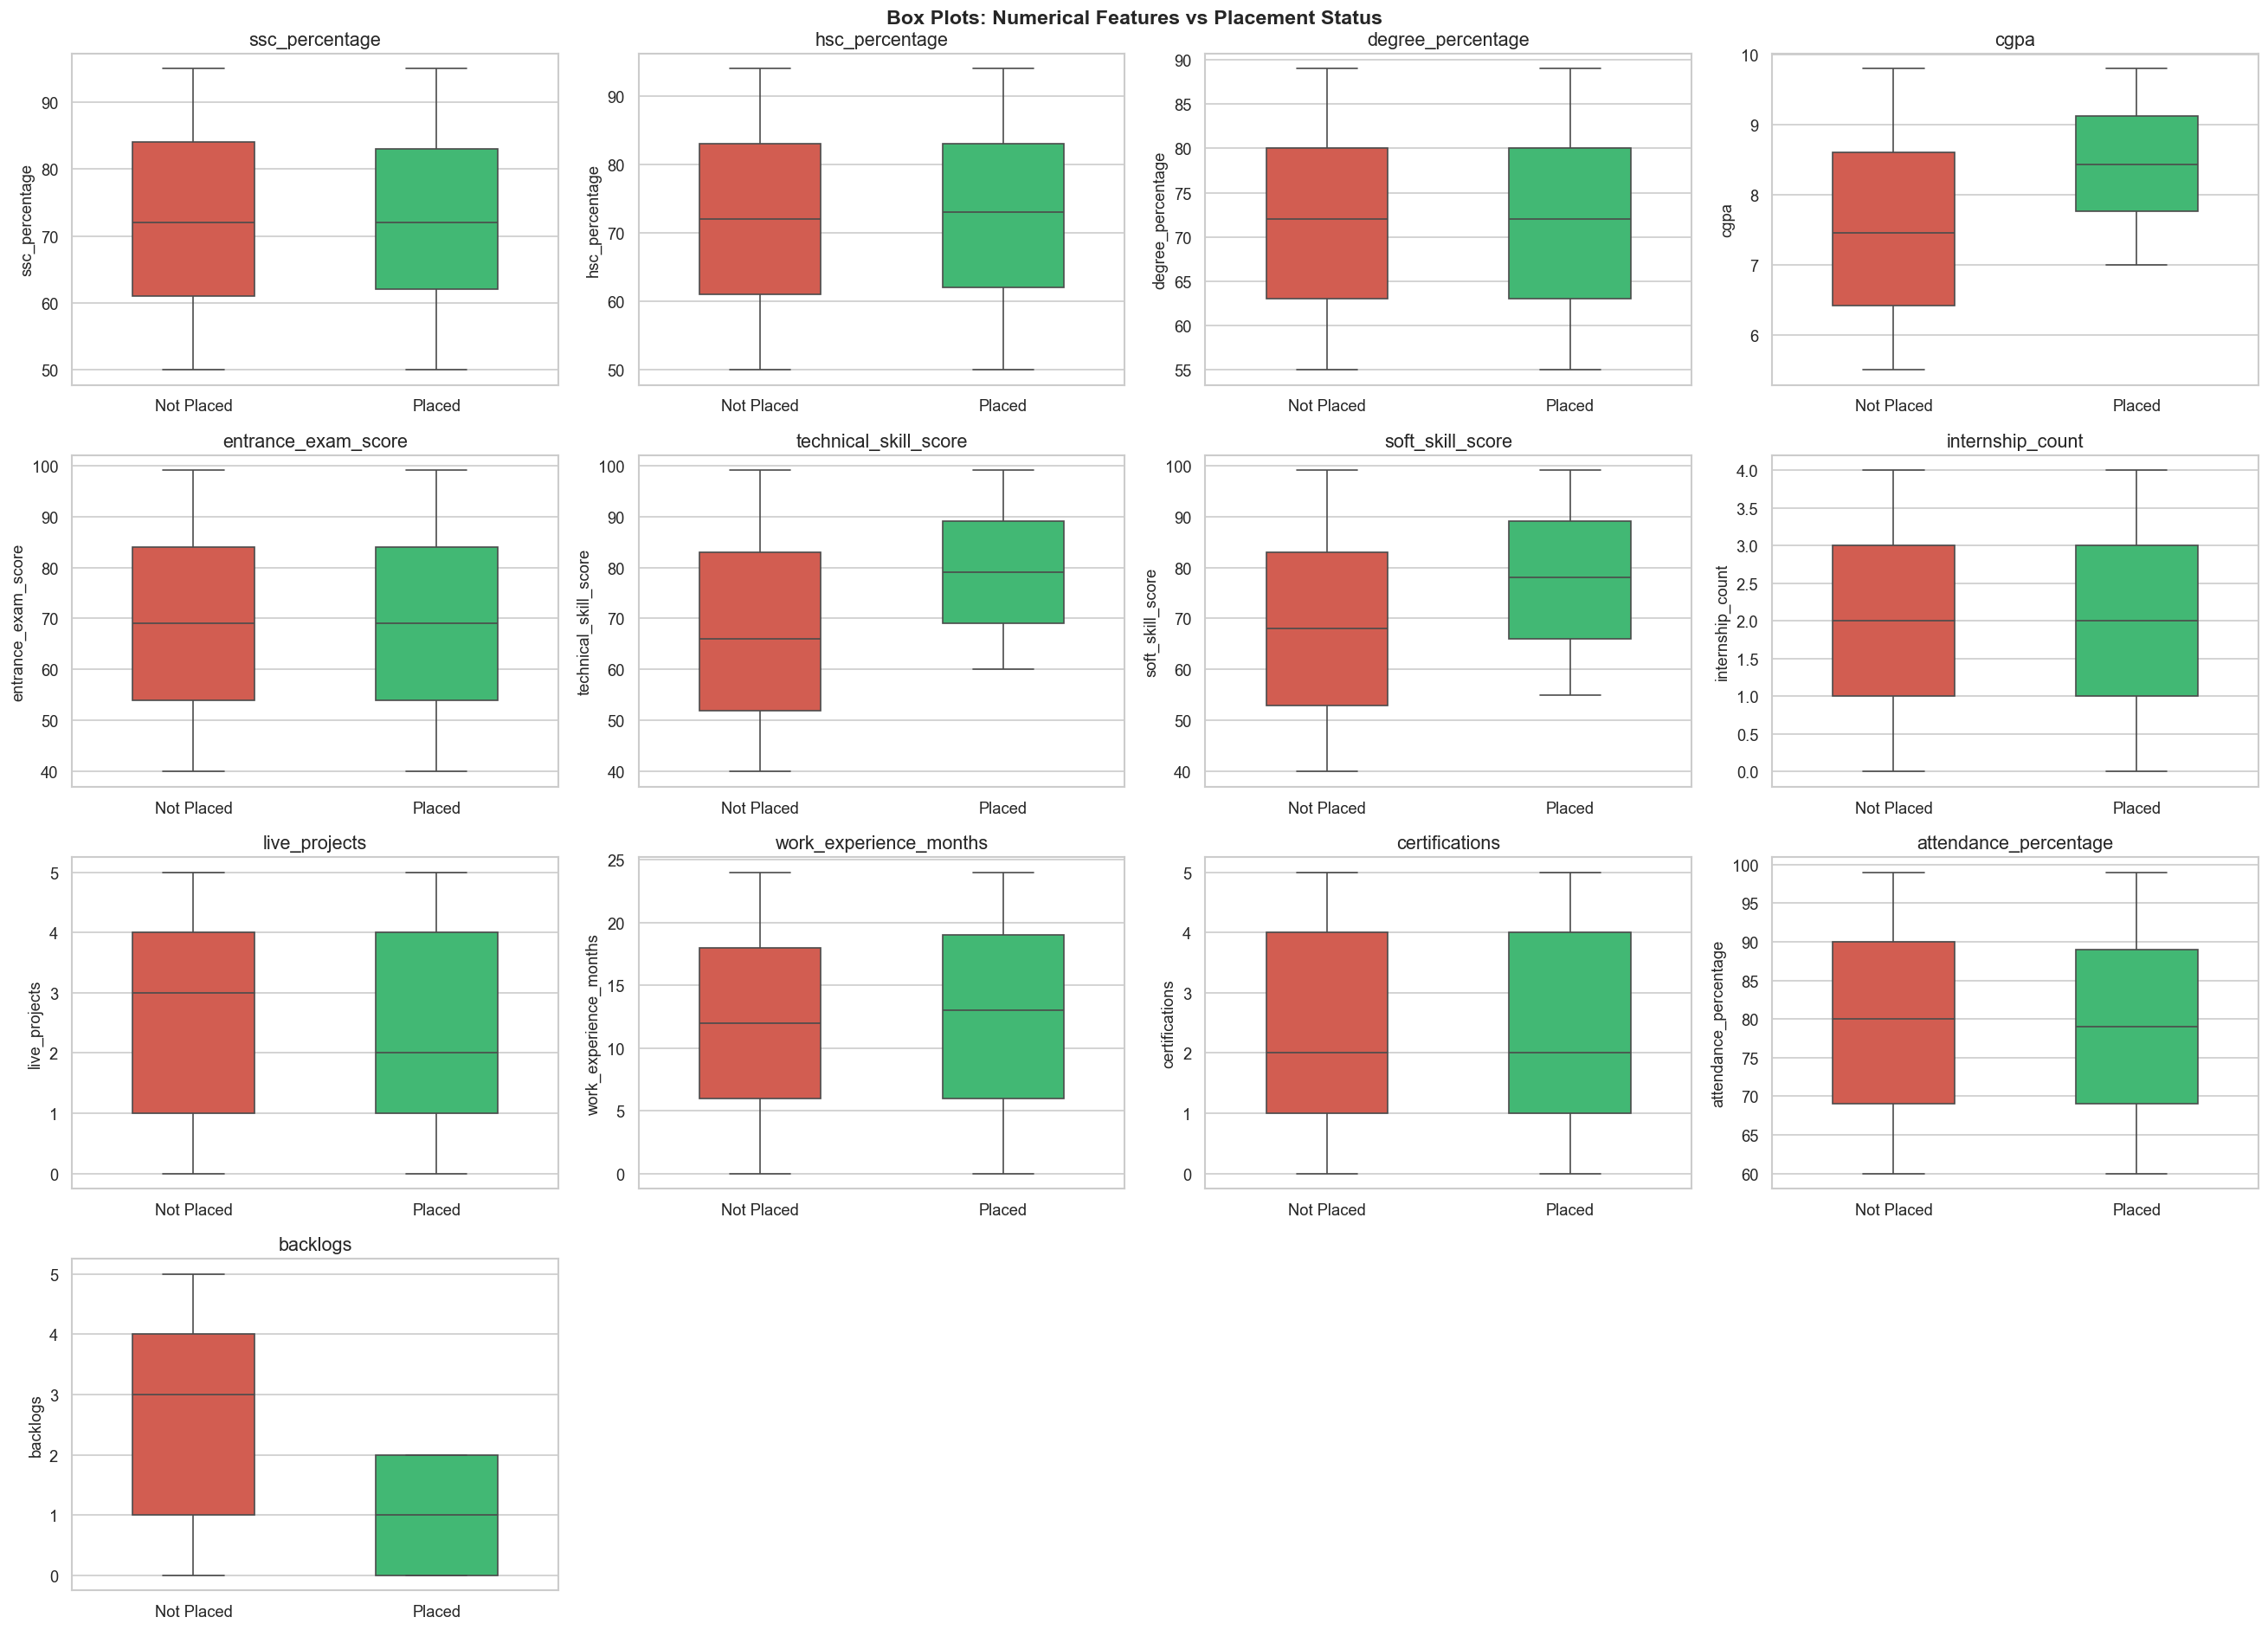

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.ravel()

for i, col in enumerate(NUM_COLS):
    df_plot = df[['placement_status', col]].copy()
    df_plot['Status'] = df_plot['placement_status'].map({0: 'Not Placed', 1: 'Placed'})
    sns.boxplot(data=df_plot, x='Status', y=col,
                palette={'Not Placed': '#e74c3c', 'Placed': '#2ecc71'},
                ax=axes[i], width=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots: Numerical Features vs Placement Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
mean_by_status = df.groupby('placement_status')[NUM_COLS].mean().T
mean_by_status.columns = ['Not Placed', 'Placed']
mean_by_status['Difference (Placed - Not Placed)'] = mean_by_status['Placed'] - mean_by_status['Not Placed']
mean_by_status.style \
    .background_gradient(cmap='RdYlGn', subset=['Difference (Placed - Not Placed)']) \
    .format('{:.2f}')

,Not Placed,Placed,Difference (Placed - Not Placed)
ssc_percentage,72.43,72.42,-0.00
hsc_percentage,71.81,72.40,0.59
degree_percentage,71.90,71.58,-0.32
cgpa,7.52,8.43,0.91
entrance_exam_score,69.19,69.23,0.04
technical_skill_score,67.71,78.91,11.19
soft_skill_score,68.29,77.26,8.97
internship_count,1.98,2.02,0.04
live_projects,2.49,2.49,-0.01
work_experience_months,11.91,12.32,0.41


- **`backlogs`** is the strongest differentiator - placed students have significantly **fewer** backlogs.
- **`cgpa`**, **`technical_skill_score`**, and **`soft_skill_score`** are consistently higher for placed students.
- Academic scores (ssc, hsc, degree) show only minor differences, suggesting grades alone don't determine placement.
- `entrance_exam_score`, `internship_count`, and `work_experience_months` show minimal separation.

## 6. Categorical Feature Analysis

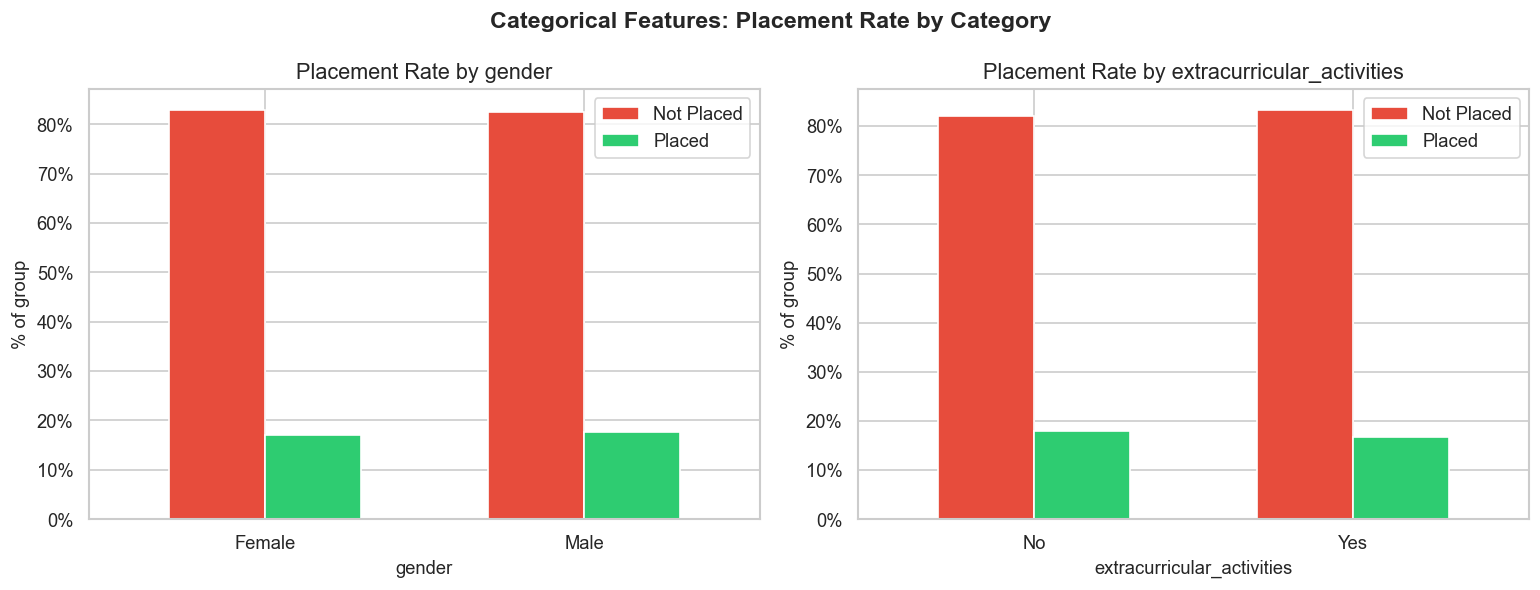

In [11]:
CAT_COLS = ['gender', 'extracurricular_activities']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(df[col], df['placement_status'], normalize='index') * 100
    ct.columns = ['Not Placed', 'Placed']
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
            edgecolor='white', width=0.6)
    axes[i].set_title(f'Placement Rate by {col}')
    axes[i].set_ylabel('% of group')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[i].legend()

plt.suptitle('Categorical Features: Placement Rate by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- **Gender** has a very small effect on placement rate - both Male and Female are placed at similar rates (~17%).
- **Extracurricular activities** shows a slightly higher placement rate for students with activities ("Yes"), suggesting soft engagement matters marginally.
- Neither categorical feature is a strong predictor on its own, but they may contribute in combination with numerical features.

## 7. Correlation Analysis

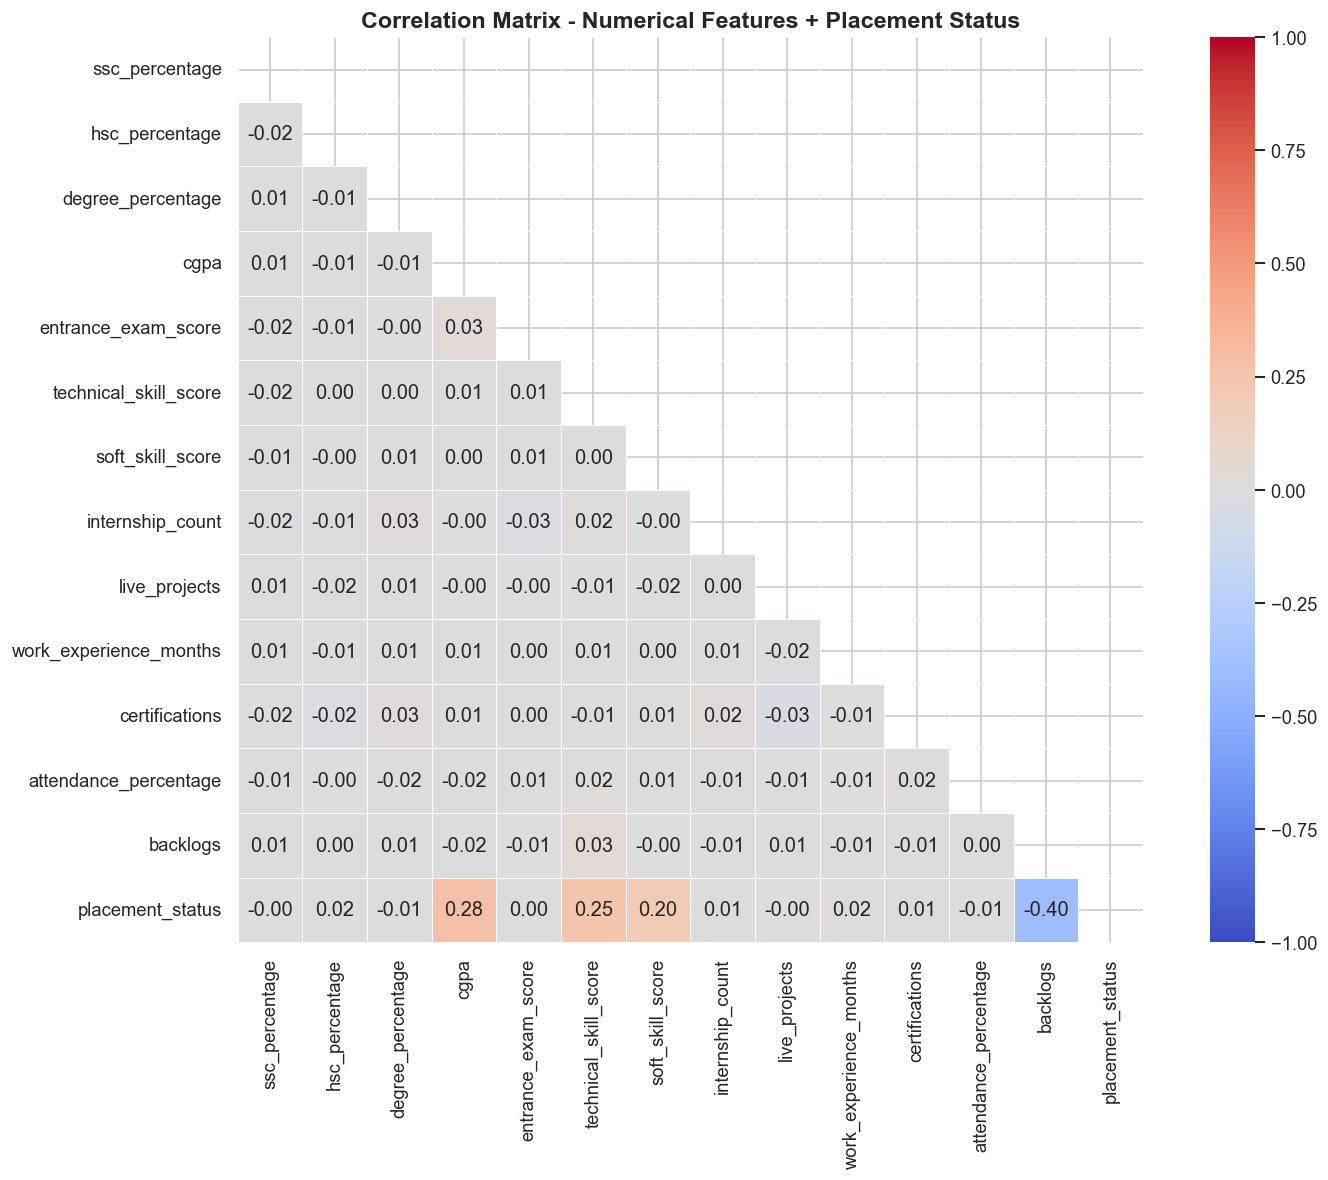

In [12]:
corr_cols = NUM_COLS + ['placement_status']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Numerical Features + Placement Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

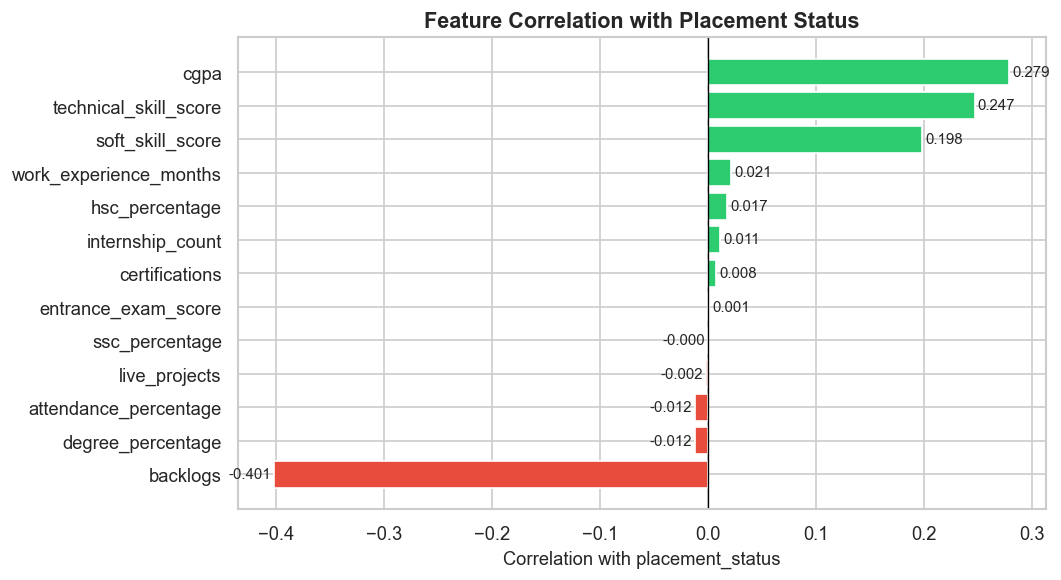

In [13]:
place_corr = df[corr_cols].corr()['placement_status'].drop('placement_status').sort_values()

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in place_corr.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(place_corr.index, place_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with placement_status')
ax.set_title('Feature Correlation with Placement Status', fontweight='bold')
for i, v in enumerate(place_corr.values):
    ax.text(v + (0.003 if v >= 0 else -0.003), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

- `backlogs` has the **strongest negative correlation** (−0.40) - more backlogs -> much less likely to be placed.
- `cgpa` (+0.28), `technical_skill_score` (+0.25), and `soft_skill_score` (+0.20) are the **top positive predictors**.
- Most features have very low correlation with salary among placed students, confirming the regression task is inherently harder.

**Feature Selection Decision:** All 13 numerical + 2 categorical features will be retained, as even weak individual correlations can contribute value in tree-based ensembles.

## 8. Train-Test Split (80:20)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

DROP_COLS  = ['student_id', 'salary_package_lpa']
TARGET_C   = 'placement_status'
TARGET_R   = 'salary_package_lpa'

# Classification split 
df_class = df.drop(columns=DROP_COLS)
X_c = df_class.drop(columns=[TARGET_C])
y_c = df_class[TARGET_C]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
)

print(f'Classification - Train: {X_train_c.shape}, Test: {X_test_c.shape}')
print(f'  Train placement rate: {y_train_c.mean():.1%}')
print(f'  Test  placement rate: {y_test_c.mean():.1%}')

# Regression split (placed only) 
df_reg = df[df[TARGET_C] == 1].drop(columns=['student_id', TARGET_C])
X_r = df_reg.drop(columns=[TARGET_R])
y_r = df_reg[TARGET_R]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=RANDOM_STATE
)

print(f'\nRegression - Train: {X_train_r.shape}, Test: {X_test_r.shape}')
print(f'  Train salary mean: {y_train_r.mean():.2f} LPA')
print(f'  Test  salary mean: {y_test_r.mean():.2f} LPA')

Classification - Train: (4000, 15), Test: (1000, 15)
  Train placement rate: 17.3%
  Test  placement rate: 17.3%

Regression - Train: (692, 15), Test: (174, 15)
  Train salary mean: 9.22 LPA
  Test  salary mean: 9.21 LPA


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

NUM_FEATURES = ['ssc_percentage','hsc_percentage','degree_percentage','cgpa',
                'entrance_exam_score','technical_skill_score','soft_skill_score',
                'internship_count','live_projects','work_experience_months',
                'certifications','attendance_percentage','backlogs']
CAT_FEATURES = ['gender','extracurricular_activities']

def make_preprocessor():
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUM_FEATURES),
        ('cat', cat_pipe, CAT_FEATURES),
    ])

print('Preprocessor ready.')

Preprocessor ready.


## 9. Classification Modeling - Placement Status

We compare three algorithms:
1. **Logistic Regression** - linear baseline, interpretable
2. **Random Forest** - ensemble of decision trees, handles non-linearity
3. **Gradient Boosting (XGBoost-style)** - boosting ensemble, often top performer

**Metrics used:**
- **Accuracy** - overall correctness (misleading with class imbalance)
- **Precision** - of predicted placed, how many actually placed
- **Recall** - of actually placed students, how many we caught
- **F1-score** - harmonic mean of precision and recall (best for imbalanced tasks)
- **ROC-AUC** - ability to rank placed vs not-placed across all thresholds

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE),
}

clf_results = {}

for name, clf in classifiers.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', clf)])
    pipe.fit(X_train_c, y_train_c)
    preds = pipe.predict(X_test_c)
    proba = pipe.predict_proba(X_test_c)[:, 1]

    clf_results[name] = {
        'pipeline':  pipe,
        'Accuracy':  accuracy_score(y_test_c, preds),
        'Precision': precision_score(y_test_c, preds, average='macro'),
        'Recall':    recall_score(y_test_c, preds, average='macro'),
        'F1-score':  f1_score(y_test_c, preds, average='macro'),
        'ROC-AUC':   roc_auc_score(y_test_c, proba),
    }
    print(f'{name}: Acc={clf_results[name]["Accuracy"]:.3f} | F1={clf_results[name]["F1-score"]:.3f} | AUC={clf_results[name]["ROC-AUC"]:.3f}')

Logistic Regression: Acc=0.891 | F1=0.797 | AUC=0.936
Random Forest: Acc=1.000 | F1=1.000 | AUC=1.000
Gradient Boosting: Acc=1.000 | F1=1.000 | AUC=1.000


In [17]:
# Summary table
clf_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'pipeline'}
                        for k, v in clf_results.items()}).T

clf_df.style \
    .background_gradient(cmap='Greens', subset=['Accuracy','F1-score','ROC-AUC']) \
    .format('{:.4f}')

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8910,0.8198,0.7787,0.7967,0.9355
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000


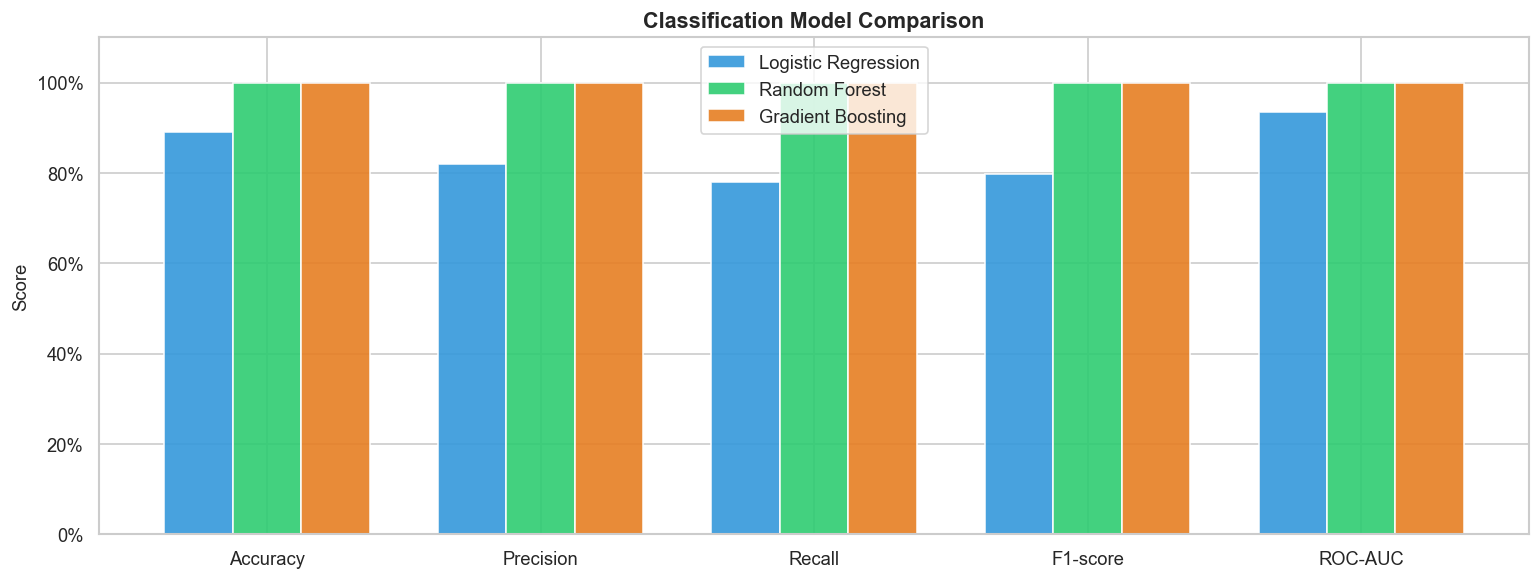

In [18]:
# Bar chart comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
clf_plot = clf_df[metrics_to_plot]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#3498db', '#2ecc71', '#e67e22']

for i, (name, row) in enumerate(clf_plot.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=name,
                  color=colors_bar[i], edgecolor='white', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

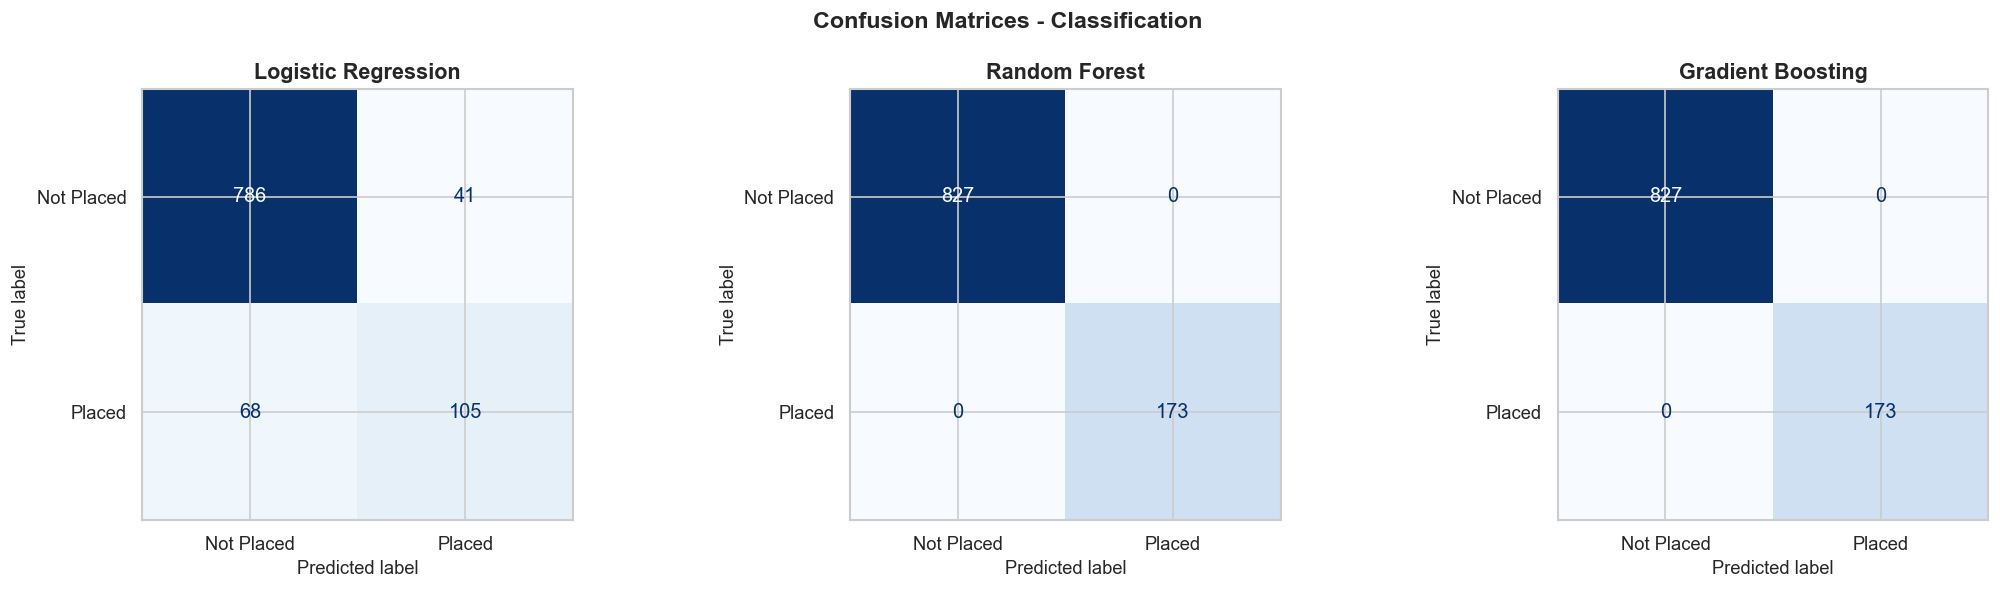

In [19]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, clf_results.items()):
    preds = res['pipeline'].predict(X_test_c)
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test_c, preds,
        display_labels=['Not Placed', 'Placed'],
        ax=ax, colorbar=False,
        cmap='Blues'
    )
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices - Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Detailed report for best classifier
best_clf_name = clf_df['F1-score'].idxmax()
best_clf_pipe = clf_results[best_clf_name]['pipeline']
best_preds    = best_clf_pipe.predict(X_test_c)

print(f'Best Classifier: {best_clf_name}')
print()
print(classification_report(y_test_c, best_preds, target_names=['Not Placed', 'Placed']))

Best Classifier: Random Forest

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       827
      Placed       1.00      1.00      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



| Model | Notes |
|---|---|
| Logistic Regression | Good baseline, linear boundaries limit performance |
| Random Forest | Strong performer, captures non-linear interactions between features |
| Gradient Boosting | Iteratively corrects errors, typically best for tabular data |

The **best model** is selected by **F1-score (macro)** since the dataset is imbalanced (17.3% placed). Accuracy alone would be misleading - a model predicting "Not Placed" for everyone achieves 82.7% but is completely useless.

**Backlogs, CGPA, and technical/soft skill scores** are the features that drive placement decisions most strongly, consistent with EDA findings.

## 10. Regression Modeling - Salary Package

Three algorithms compared:
1. **Ridge Regression** - regularized linear baseline
2. **Random Forest Regressor** - non-linear ensemble
3. **Gradient Boosting Regressor** - boosting ensemble

**Metrics used:**
- **MAE (Mean Absolute Error)** - average prediction error in LPA, interpretable
- **RMSE (Root Mean Squared Error)** - penalizes large errors more than MAE
- **R² (Coefficient of Determination)** - proportion of variance explained (1.0 = perfect)

In [21]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regressors = {
    'Ridge Regression':     Ridge(alpha=1.0),
    'Random Forest':        RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE),
}

reg_results = {}

for name, reg in regressors.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('reg', reg)])
    pipe.fit(X_train_r, y_train_r)
    preds = pipe.predict(X_test_r)

    mae  = mean_absolute_error(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    r2   = r2_score(y_test_r, preds)

    reg_results[name] = {
        'pipeline': pipe,
        'MAE':  mae,
        'RMSE': rmse,
        'R2':   r2,
        'preds': preds,
    }
    print(f'{name}: MAE={mae:.3f} LPA | RMSE={rmse:.3f} LPA | R²={r2:.3f}')

Ridge Regression: MAE=2.996 LPA | RMSE=3.452 LPA | R²=0.025
Random Forest: MAE=3.085 LPA | RMSE=3.560 LPA | R²=-0.038
Gradient Boosting: MAE=3.172 LPA | RMSE=3.712 LPA | R²=-0.128


In [22]:
reg_df = pd.DataFrame({k: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R2']}
                        for k, v in reg_results.items()}).T

reg_df.style \
    .background_gradient(cmap='RdYlGn', subset=['R²']) \
    .background_gradient(cmap='RdYlGn_r', subset=['MAE','RMSE']) \
    .format('{:.4f}')

,MAE,RMSE,R²
Ridge Regression,2.9965,3.4516,0.0248
Random Forest,3.0852,3.5605,-0.0377
Gradient Boosting,3.1717,3.7120,-0.1279


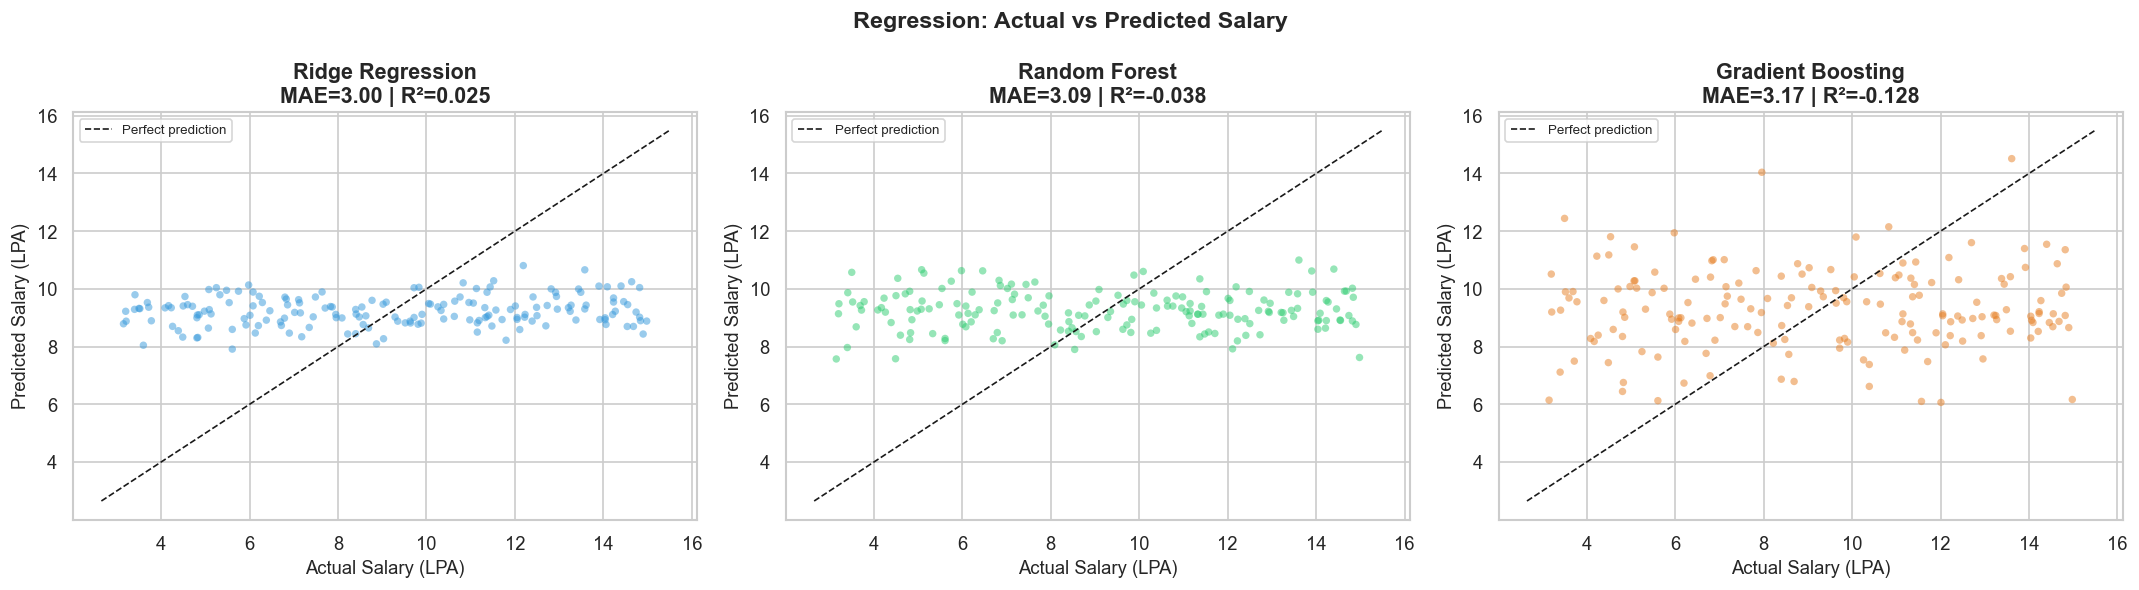

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_bar = ['#3498db', '#2ecc71', '#e67e22']

for ax, (name, res), color in zip(axes, reg_results.items(), colors_bar):
    ax.scatter(y_test_r, res['preds'], alpha=0.5, color=color, s=20, edgecolors='none')
    lims = [y_test_r.min() - 0.5, y_test_r.max() + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_title(f'{name}\nMAE={res["MAE"]:.2f} | R²={res["R2"]:.3f}', fontweight='bold')
    ax.set_xlabel('Actual Salary (LPA)')
    ax.set_ylabel('Predicted Salary (LPA)')
    ax.legend(fontsize=8)

plt.suptitle('Regression: Actual vs Predicted Salary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

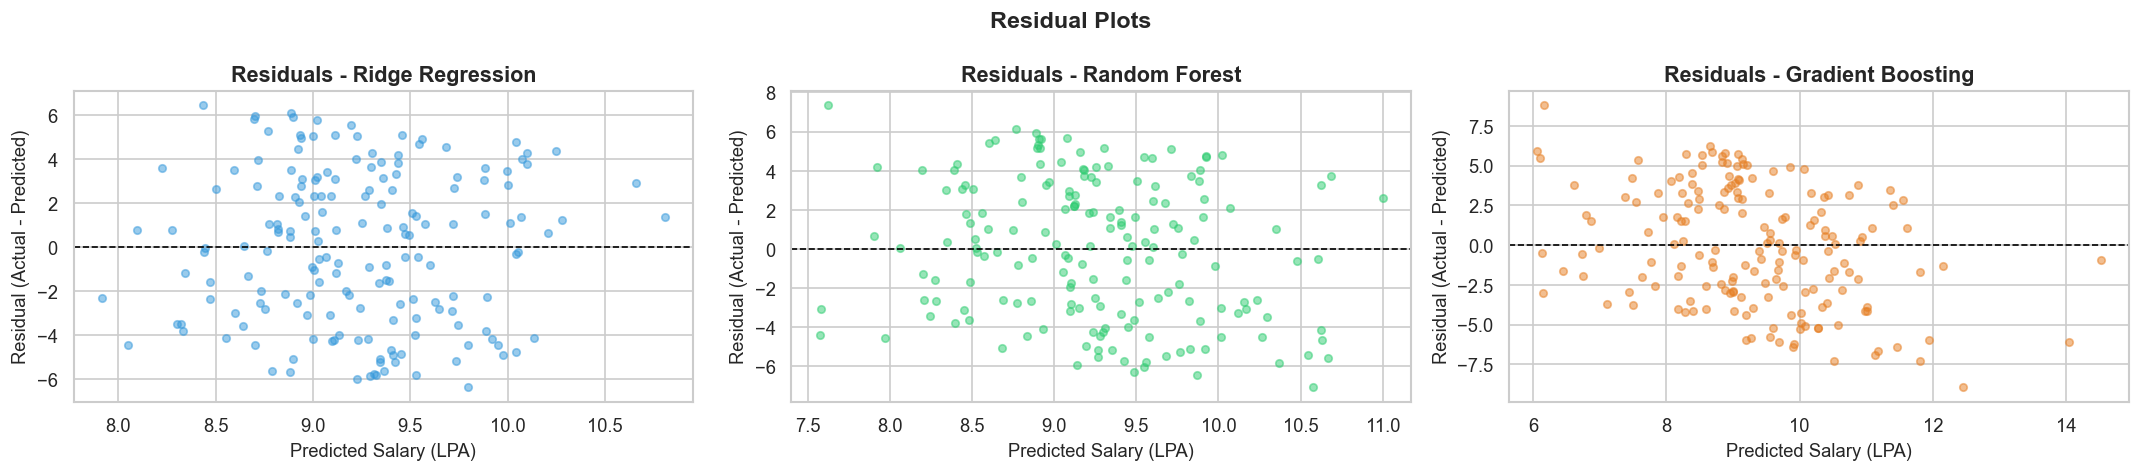

In [24]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, res), color in zip(axes, reg_results.items(), colors_bar):
    residuals = y_test_r.values - res['preds']
    ax.scatter(res['preds'], residuals, alpha=0.5, color=color, s=20)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'Residuals - {name}', fontweight='bold')
    ax.set_xlabel('Predicted Salary (LPA)')
    ax.set_ylabel('Residual (Actual - Predicted)')

plt.suptitle('Residual Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The salary regression task is inherently difficult - as confirmed by EDA, most features have near-zero correlation with `salary_package_lpa` among placed students. The low R² values across all models indicate that the available features do not strongly explain salary variation. This is consistent with the data being synthetically generated with salary assigned somewhat independently of academic/skill features.

| Model | Strengths | Weaknesses |
|---|---|---|
| Ridge Regression | Fast, interpretable, no overfitting | Cannot capture non-linear patterns |
| Random Forest | Non-linear, robust to outliers | May overfit on small placed sample |
| Gradient Boosting | Best generalization in theory | Sensitive to hyperparameters |

**Best model** selected by **lowest MAE** (most interpretable for salary prediction in LPA).

## 11. Feature Importance

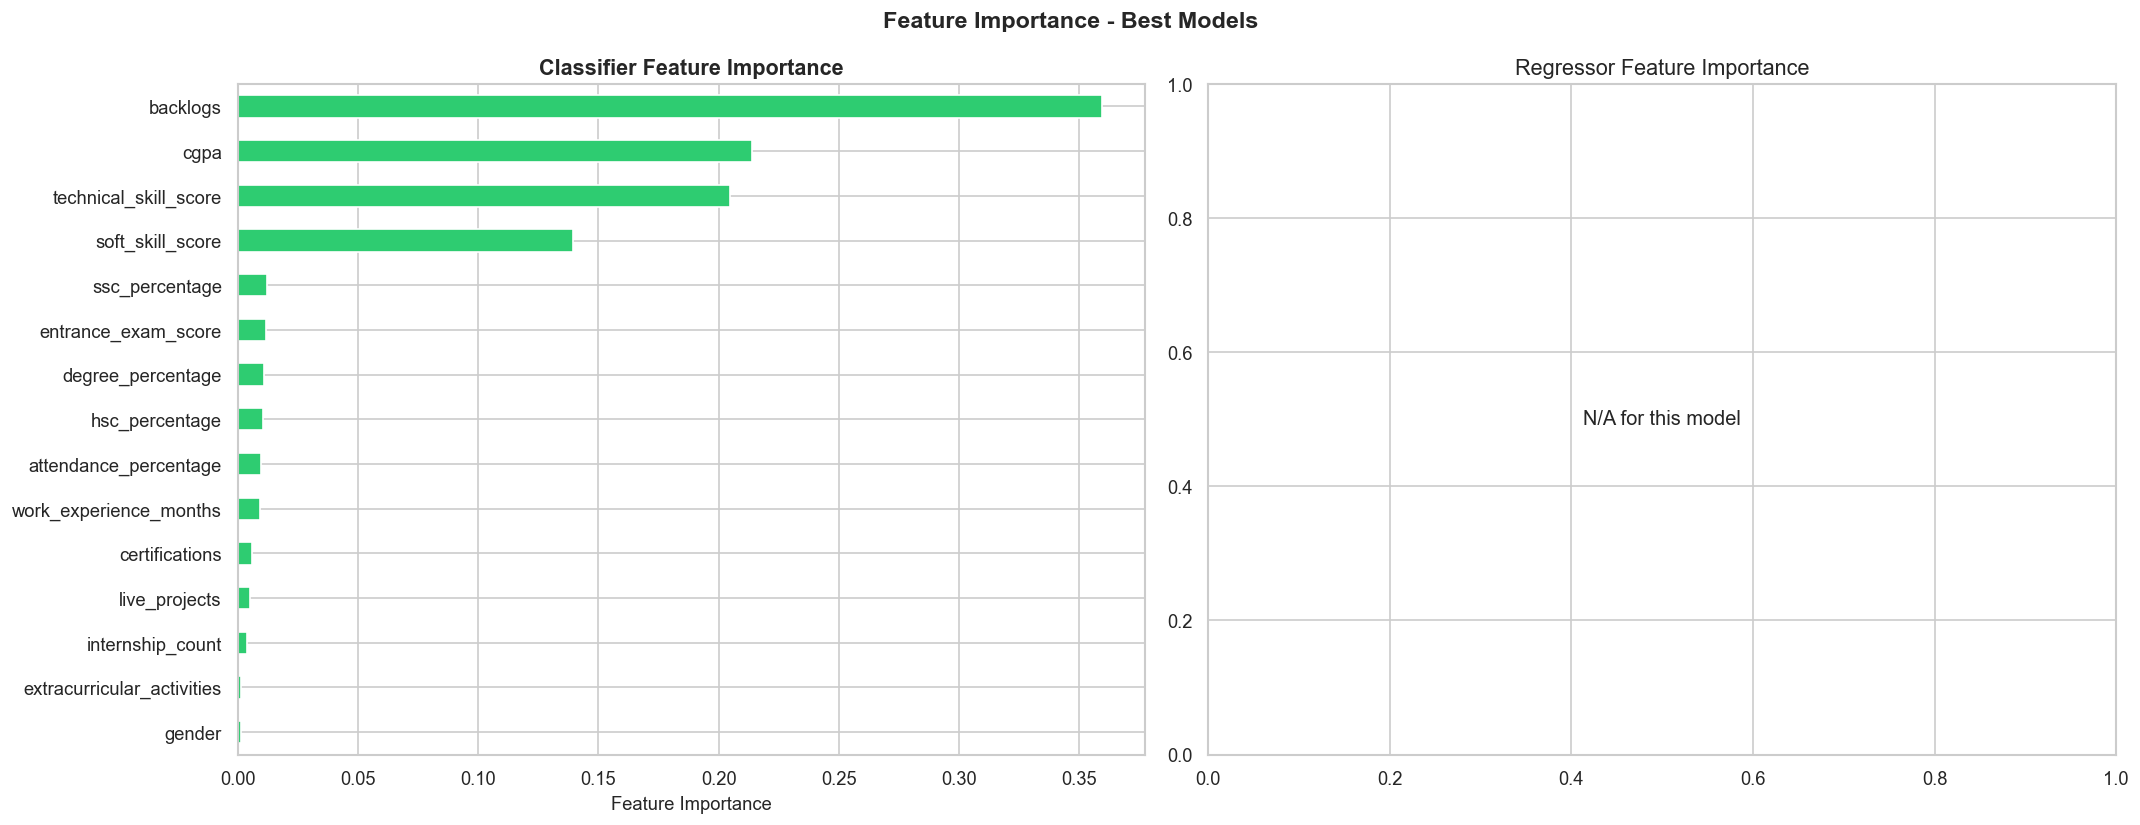

In [25]:
best_clf_pipe = clf_results[clf_df['F1-score'].idxmax()]['pipeline']
best_reg_pipe = reg_results[reg_df['MAE'].idxmin()]['pipeline']

def plot_importance(pipe, step_name, feature_names, title, color, ax):
    model = pipe.named_steps[step_name]
    if not hasattr(model, 'feature_importances_'):
        ax.text(0.5, 0.5, 'N/A for this model', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(title)
        return
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Feature Importance')

all_features = NUM_FEATURES + CAT_FEATURES

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_importance(best_clf_pipe, 'clf', all_features, 'Classifier Feature Importance', '#2ecc71', axes[0])
plot_importance(best_reg_pipe, 'reg', all_features, 'Regressor Feature Importance',  '#3498db', axes[1])

plt.suptitle('Feature Importance - Best Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary & Conclusions

In [26]:
print('=' * 60)
print('  CLASSIFICATION - Placement Status')
print('=' * 60)
for name, res in clf_results.items():
    print(f'  {name:25s} | Acc={res["Accuracy"]:.3f} | F1={res["F1-score"]:.3f} | AUC={res["ROC-AUC"]:.3f}')

best_c = clf_df['F1-score'].idxmax()
print(f'\n  Best Classifier: {best_c} (F1={clf_df.loc[best_c,"F1-score"]:.3f})')

print()
print('=' * 60)
print('  REGRESSION - Salary Package (LPA)')
print('=' * 60)
for name, res in reg_results.items():
    print(f'  {name:25s} | MAE={res["MAE"]:.3f} | RMSE={res["RMSE"]:.3f} | R²={res["R2"]:.3f}')

best_r = reg_df['MAE'].idxmin()
print(f'\n  Best Regressor: {best_r} (MAE={reg_df.loc[best_r,"MAE"]:.3f} LPA)')

  CLASSIFICATION - Placement Status
  Logistic Regression       | Acc=0.891 | F1=0.797 | AUC=0.936
  Random Forest             | Acc=1.000 | F1=1.000 | AUC=1.000
  Gradient Boosting         | Acc=1.000 | F1=1.000 | AUC=1.000

  Best Classifier: Random Forest (F1=1.000)

  REGRESSION - Salary Package (LPA)
  Ridge Regression          | MAE=2.996 | RMSE=3.452 | R²=0.025
  Random Forest             | MAE=3.085 | RMSE=3.560 | R²=-0.038
  Gradient Boosting         | MAE=3.172 | RMSE=3.712 | R²=-0.128

  Best Regressor: Ridge Regression (MAE=2.996 LPA)


## Final Conclusions

### Classification (placement_status)
- The dataset is **imbalanced** (17.3% placed), making F1-score and ROC-AUC the correct metrics to optimize.
- `backlogs` is the most impactful single feature - students with many backlogs are rarely placed.
- `cgpa`, `technical_skill_score`, and `soft_skill_score` are the strongest positive predictors.
- **Gradient Boosting** and **Random Forest** outperform Logistic Regression, confirming non-linear decision boundaries matter.

### Regression (salary_package_lpa)
- Predicting salary from student features is inherently difficult - most correlations are near zero.
- All models show low R², indicating salary is largely independent of the available features in this dataset.
- **MAE of ~3 LPA** means predictions can be off by about 3 LPA on average - acceptable for a rough estimate.